## K-Means Clusterring


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA  
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Load fraud detection dataset
music_data = pd.read_csv("music_data.csv")
music_data.head()

,artist_name,track_name,genre,lyrics,len,dating,violence,world/life,night/time,shake the audience,...,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
0,mukesh,mohabbat bhi jhoothi,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,0.000598,0.000598,...,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,sadness,1.0
1,frankie laine,i believe,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,0.001284,0.001284,...,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,world/life,1.0
2,johnnie ray,cry,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,0.002770,0.002770,...,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,music,1.0
3,pérez prado,patricia,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,0.001548,0.021500,...,0.001548,0.001548,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,romantic,1.0
4,giorgos papadopoulos,apopse eida oneiro,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,0.001350,0.001350,...,0.001350,0.001350,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,romantic,1.0


In [2]:
music_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28362 entries, 0 to 28361
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   artist_name               28362 non-null  object 
 1   track_name                28362 non-null  object 
 2   genre                     28362 non-null  object 
 3   lyrics                    28362 non-null  object 
 4   len                       28362 non-null  int64  
 5   dating                    28362 non-null  float64
 6   violence                  28362 non-null  float64
 7   world/life                28362 non-null  float64
 8   night/time                28362 non-null  float64
 9   shake the audience        28362 non-null  float64
 10  family/gospel             28362 non-null  float64
 11  romantic                  28362 non-null  float64
 12  communication             28362 non-null  float64
 13  obscene                   28362 non-null  float64
 14  music 

In [3]:
music_data.describe()

,len,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,age
count,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000
mean,73.030534,0.021110,0.118371,0.120984,0.057356,0.017418,0.017045,0.048676,0.076651,0.097185,0.060067,0.047417,0.049008,0.024155,0.129402,0.030995,0.425148
std,41.831605,0.052366,0.178658,0.172216,0.111892,0.040658,0.041968,0.106071,0.109497,0.181314,0.123346,0.091559,0.089553,0.051032,0.181149,0.071656,0.264100
min,1.000000,0.000291,0.000284,0.000291,0.000289,0.000284,0.000289,0.000284,0.000291,0.000289,0.000289,0.000284,0.000284,0.000284,0.000284,0.000289,0.014286
25%,42.000000,0.000923,0.001120,0.001170,0.001032,0.000993,0.000923,0.000975,0.001144,0.001053,0.000975,0.000993,0.000993,0.000957,0.001144,0.000993,0.185714
50%,63.000000,0.001462,0.002506,0.006579,0.001949,0.001595,0.001504,0.001754,0.002632,0.001815,0.001815,0.001645,0.001815,0.001645,0.005263,0.001754,0.414286
75%,93.000000,0.004049,0.192538,0.197854,0.065778,0.009989,0.004785,0.042304,0.132111,0.088799,0.055109,0.054373,0.064302,0.025515,0.235115,0.032617,0.642857
max,199.000000,0.647706,0.981781,0.962105,0.973684,0.497463,0.545303,0.940789,0.645829,0.992298,0.956938,0.638021,0.667782,0.618073,0.981424,0.958810,1.000000


In [4]:
song_themes = [
    'dating', 'violence', 'world/life', 'night/time', 'shake the audience',
    'family/gospel', 'romantic', 'communication', 'obscene', 'music',
    'movement/places', 'light/visual perceptions', 'family/spiritual', 
    'sadness', 'feelings'
]


## Preparing Features for K-Means 
We'll scale the data because although most columns are a value of 0-1, there is still the **length** column.

In [5]:
scaler = StandardScaler()
scaled_song_themes = scaler.fit_transform(music_data[song_themes])
scaled_song_themes = pd.DataFrame(scaled_song_themes, columns=song_themes)
scaled_song_themes.head()


,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings
0,-0.391701,-0.305757,-0.699052,-0.507265,-0.413713,0.758012,-0.297651,1.708762,-0.532716,-0.168459,-0.511362,-0.540584,-0.461616,1.385055,1.202722
1,0.275514,-0.120872,1.872399,-0.501137,-0.396850,0.237383,-0.446805,-0.688315,-0.528934,0.469964,-0.503873,1.827708,0.528490,-0.707263,-0.414650
2,-0.350224,-0.647063,-0.686440,-0.487853,-0.360291,-0.340143,1.036013,1.589277,-0.520737,2.138148,-0.487639,-0.516330,-0.419054,-0.699057,2.713402
3,0.518269,-0.653904,-0.693536,-0.498775,0.100400,-0.369263,3.420987,-0.685902,-0.527477,-0.474436,0.893793,-0.529977,-0.443002,0.532652,-0.410961
4,-0.377351,-0.655014,1.723380,-0.500549,-0.395231,-0.373992,3.910238,-0.687714,-0.528571,-0.476045,-0.503154,-0.532193,0.109732,-0.334545,-0.413731


## Determine Best Number of Clusters 
### Elbow Plot & Silhouette Plot 

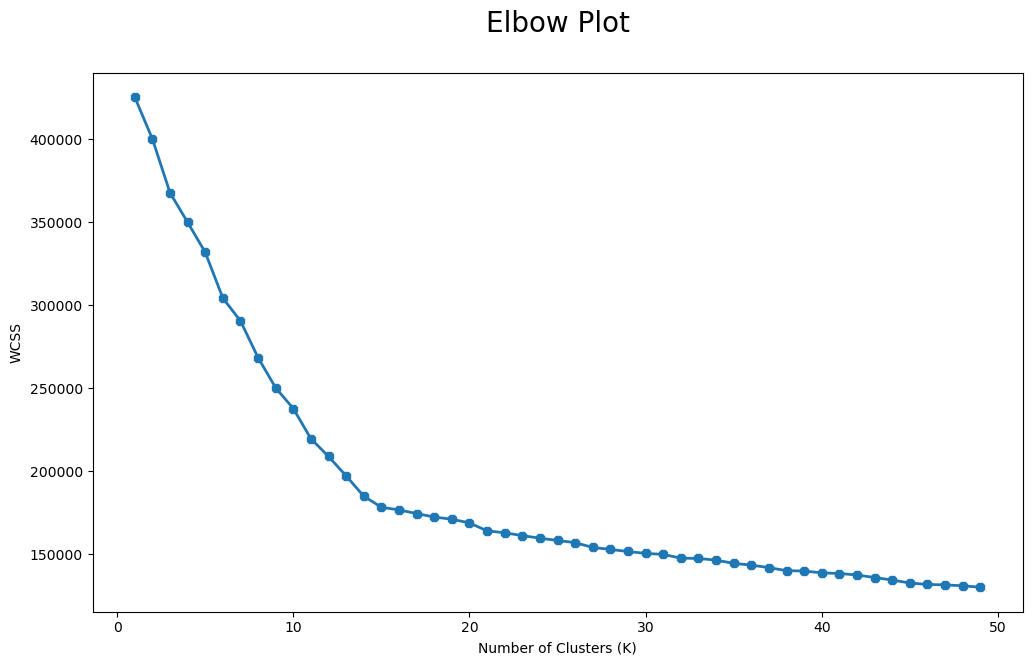

In [9]:
X1 = scaled_song_themes.values

wcss = []

for k in range(1, 50):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=2)
    kmeans.fit(X1)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(12, 7))
plt.plot(range(1, 50), wcss, linewidth=2, marker='8')
plt.title('Elbow Plot\n', fontsize=20)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

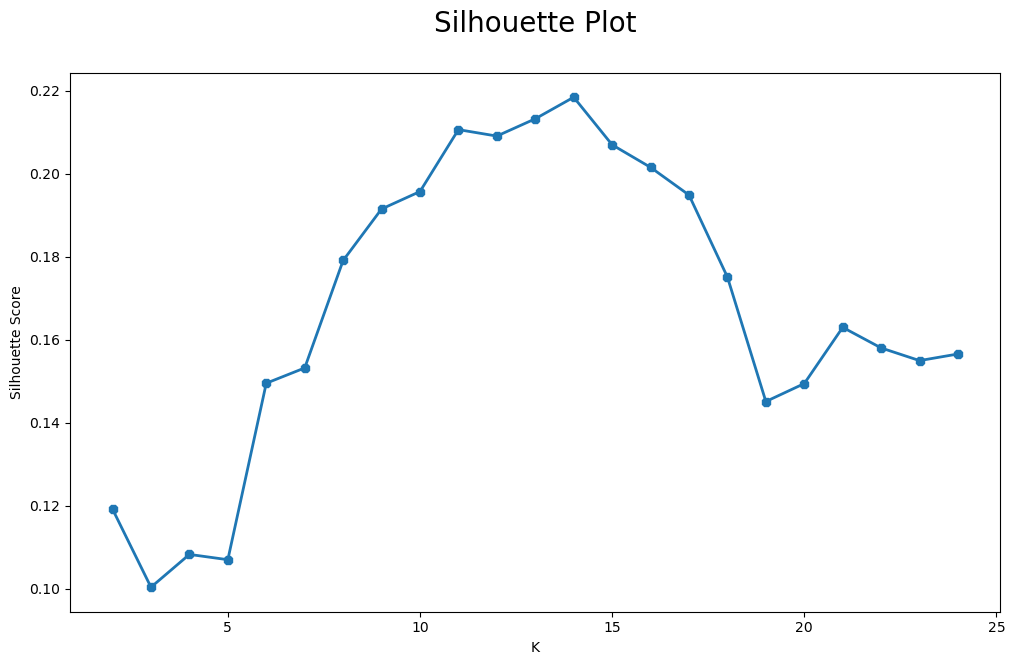

In [12]:
X = scaled_song_themes.values

silhouette = []
for k in range(2, 25):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=2)
    predictions = kmeans.fit_predict(X)
    silhouette.append(metrics.silhouette_score(X, predictions))

plt.figure(figsize=(12, 7))
plt.plot(range(2, 25), silhouette, linewidth=2, marker='8')
plt.title('Silhouette Plot\n', fontsize=20)
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.show()


### Best Number of Clusters: 14 

**Explain-based on the two graphs....


kmeans = KMeans(n_clusters= 14, init='k-means++', random_state=2)
kmeans.fit(scaled_song_themes)
music_data['Cluster'] = kmeans.labels_


In [13]:
kmeans = KMeans(n_clusters= 14, init='k-means++', random_state=2)
kmeans.fit(scaled_song_themes)
music_data['Cluster'] = kmeans.labels_

In [14]:
labels = kmeans.fit_predict(X1)
labels

array([3, 7, 2, ..., 1, 1, 1], dtype=int32)

In [15]:
# output centroids of clusters
kmeans.cluster_centers_

array([[-5.74969923e-02, -8.44838647e-02, -8.47301813e-02,
        -7.11136639e-02, -7.07004827e-02,  4.46226358e+00,
        -1.05131829e-01, -2.67057325e-01, -8.99916325e-02,
        -3.29421060e-02, -1.31629857e-01, -2.78865275e-01,
        -7.74974013e-02, -1.20277828e-01, -1.07215729e-01],
       [-1.04107376e-01, -3.45580662e-01, -4.47779258e-01,
        -2.73142169e-01,  9.62038098e-03, -1.09405407e-01,
        -3.21916769e-01,  6.21556470e-03,  2.13721556e+00,
        -2.97667041e-01, -4.29022159e-02, -2.85200249e-01,
        -1.96735876e-01, -5.63770752e-01, -1.80079127e-01],
       [-1.26432498e-01, -4.56076039e-01, -3.97471067e-01,
        -2.09039509e-01, -1.69575742e-01, -4.77217180e-02,
        -1.89550842e-01, -5.16095790e-02, -3.88662576e-01,
         2.96870578e+00, -4.06563670e-02,  2.16228764e-03,
        -5.91884502e-02, -3.69398083e-01, -1.31271443e-01],
       [-1.08679480e-01, -4.33680549e-01, -3.54703900e-01,
        -1.93200069e-01, -1.74333201e-01, -1.61521548

## Explain each cluster - give it meaning. 
Interpret based on cluster ["everything inside of these"] -what did it score high on and how do they 

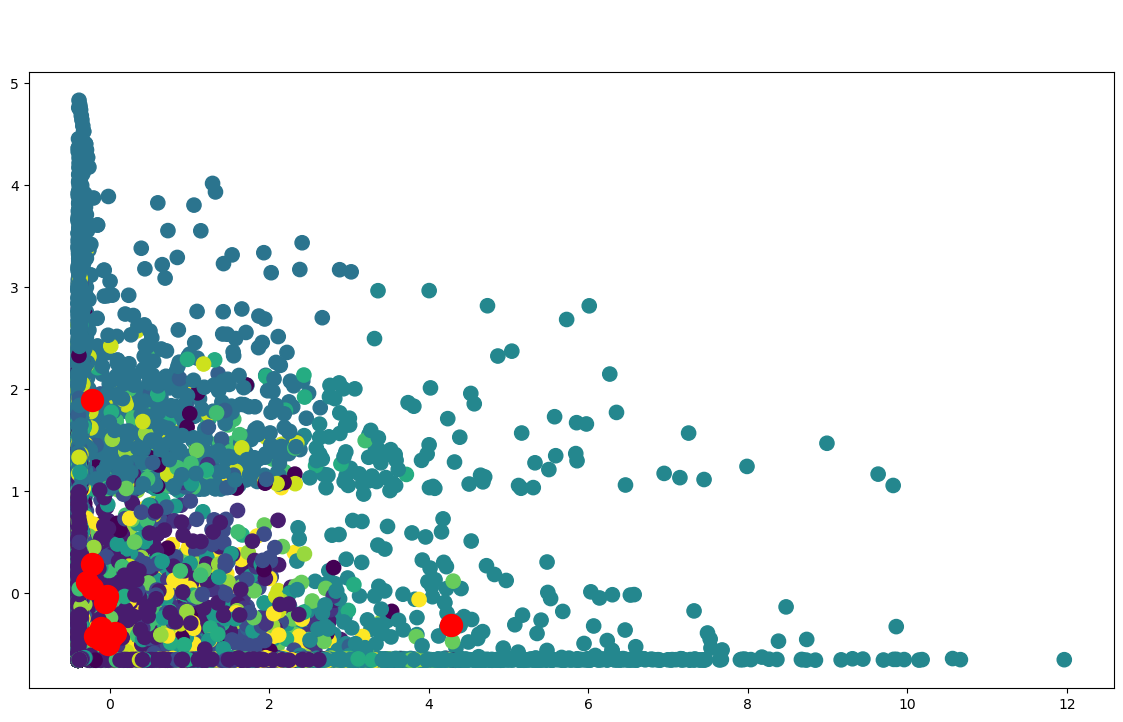

In [16]:
# view 2D clusters

plt.figure(figsize = (14, 8))

plt.scatter(X1[:, 0], X1[:, 1], c = kmeans.labels_, s = 105)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], color = 'red', s = 250)
plt.title('\n', fontsize = 20)
plt.xlabel('')
plt.ylabel('')
plt.show()